This code preprocesses the clinical+gex corrected data, train and validate a logistic regression, save the best model for explanability.<br>
This pipeline contains data leakage on the gene columns because we select best 20 genes before splitting data into train and test set.<br>
However, the preprocessing data pipeline is fitted only on train set, then transformed on test set, so no data leakage on this part.

Import libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import (
    StratifiedKFold, LeaveOneGroupOut,
    cross_validate, cross_val_predict, cross_val_score,
)
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import pacmap

from sklearn.metrics import f1_score, roc_auc_score
import shap

Same configurations

In [16]:
BINARY_PFS = True
RNA_SEQ_ONLY = True

pfs_dir = "binary" if BINARY_PFS else "three-classes"
rna_suffix = "_rna" if RNA_SEQ_ONLY else ""

Load data

In [17]:
# Load gex_mat_corrected
gex_mat = pd.read_csv(f"../dataset/created/{pfs_dir}/gex_mat_corrected{rna_suffix}.csv").set_index('sample_id').T
gex_mat['sample_id'] = gex_mat.index

# print(gex_mat.shape)
# gex_mat.head()

In [18]:
# Load clinical_gex
clinical_gex = pd.read_csv(f"../dataset/created/{pfs_dir}/clinical_gex{rna_suffix}.csv", low_memory=False)

# print(clinical_gex.shape)
# clinical_gex.head()

Grouping features based on type

In [19]:
# Clinical feature groups
clinical_ordinal_col    = ['M_stage']
clinical_categorical_cols = ['sex', 'AJCC_stage', 'LDH', 'immunotherapy_treatment', 'pre_MAPKi_treatment']
clinical_numeric_col    = ['age']
clinical_drug_braf_cols = ['cobimetinib', 'trametinib', 'dabrafenib', 'vemurafenib',
                           'C195W', 'K601I', 'MND', 'V600E', 'V600K', 'V600R'] 
clinical_remaining_cols = ['patientID', 'sample_id', 'pfs_label', 'source']

# sometime certain drugs or gene are missing in the dataset
clinical_drug_braf_cols = [c for c in clinical_drug_braf_cols if c in clinical_gex.columns]

CLINICAL_COLS = (clinical_ordinal_col + clinical_categorical_cols + clinical_numeric_col
                + clinical_drug_braf_cols + clinical_remaining_cols)

GEX_COLS_ORI = [c for c in clinical_gex.columns if c not in CLINICAL_COLS]

# print('Original clinical_gex features:')
# print(f'clinical + gex = {len(CLINICAL_COLS)} + {len(GEX_COLS_ORI)} = {len(CLINICAL_COLS)+len(GEX_COLS_ORI)}')

Load the batch corrected gex matrix, replace the genes in clinical+gex dataset with corrected one

In [20]:
# Merge into clinical_gex_corrected
clinical_gex_filtered = clinical_gex[CLINICAL_COLS]
clinical_gex_filtered

clinical_gex_filtered = clinical_gex_filtered.merge(gex_mat, on='sample_id', how='inner')
print(clinical_gex_filtered.shape)
clinical_gex_filtered.head()

(78, 23404)


,M_stage,sex,AJCC_stage,LDH,immunotherapy_treatment,pre_MAPKi_treatment,age,cobimetinib,trametinib,dabrafenib,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
0,M1B,male,IV,elevated,no,no,26,0,0,0,...,2.671622,3.097789,0.556946,1.192834,2.773766,0.052665,2.079754,6.546661,2.954971,2.939248
1,M1A,female,IV,normal,no,no,58,0,0,0,...,2.973160,3.505208,0.697100,1.042928,2.612191,-0.003464,2.432721,5.618133,2.969150,2.586618
2,M1A,male,IV,normal,no,no,45,0,0,0,...,3.652098,2.859687,0.707183,1.066919,2.500457,0.260227,2.217228,6.528220,3.161277,3.463558
3,NaN,male,IIIC,normal,no,no,48,1,0,0,...,2.360416,2.718169,0.797301,1.066046,2.408641,-0.027371,2.047882,6.690812,3.135011,2.232254
4,M1C,male,IV,normal,no,no,33,1,0,0,...,3.004662,1.821515,0.810193,1.336957,2.891467,-0.052370,2.847988,5.547082,3.319700,3.505455


In [21]:
GEX_COLS_FILTERED = [c for c in clinical_gex_filtered.columns if c not in CLINICAL_COLS]

# print('Filtered clinical_gex features:')
# print(f'clinical + gex = {len(CLINICAL_COLS)} + {len(GEX_COLS_FILTERED)} = {len(CLINICAL_COLS)+len(GEX_COLS_FILTERED)}')

Feature selection on gex columns

In [22]:
clinical_gex_filtered.columns = clinical_gex_filtered.columns.str.strip()
y = clinical_gex_filtered['pfs_label']

pre_selection_pipe = Pipeline([
    ('threshold', VarianceThreshold(threshold=0.1)),
    ('seleckbest', SelectKBest(f_classif, k=20)),
])

gex_cols_selected = clinical_gex_filtered[GEX_COLS_FILTERED]
gex_cols_selected = pre_selection_pipe.fit_transform(gex_cols_selected, y)
gex_cols_selected = pre_selection_pipe.get_feature_names_out()
gex_cols_selected

array(['ADAM9', 'ALDH5A1', 'CLN8', 'CXCR5', 'DOCK1', 'FANCC', 'LATS2',
       'MIR23B', 'NME7', 'NOTCH1', 'PGM3', 'POU5F1B', 'PTPDC1', 'PYROXD2',
       'REEP4', 'SLC25A26', 'SLC36A1', 'STX2', 'TBC1D1', 'TTYH3'],
      dtype=object)

In [23]:
features_after_vt = pre_selection_pipe['threshold'].get_feature_names_out()
f_values = pre_selection_pipe['seleckbest'].scores_

f_series = pd.Series(f_values, index=features_after_vt).sort_values(ascending=False)
print("Top 20 genes by ANOVA F-value:")
print(f_series.head(20).to_string())

# fig, ax = plt.subplots(figsize=(8, 4),  dpi=150)
# sns.kdeplot(f_values, ax=ax, fill=True)
# ax.set_xlabel('ANOVA F-value')
# ax.set_ylabel('Density')
# ax.set_title('Distribution of ANOVA F-values across GEx features')
# plt.tight_layout()
# plt.show()

Top 20 genes by ANOVA F-value:
ALDH5A1     18.953890
CXCR5       16.364249
SLC25A26    15.406767
STX2        15.219638
DOCK1       15.109000
NME7        14.925650
MIR23B      14.908627
TTYH3       14.044945
FANCC       13.446662
NOTCH1      13.318005
SLC36A1     13.297323
CLN8        13.256516
TBC1D1      12.815486
PYROXD2     12.638027
PGM3        12.567910
PTPDC1      12.474354
LATS2       12.347593
POU5F1B     12.312880
REEP4       12.251256
ADAM9       12.233773


In [24]:
if y.nunique() == 2:
    BINARY_PFS = True
elif y.nunique() == 3:
    BINARY_PFS = False
else:
    raise ValueError('NOT BINARY NOR 3 CLASSES!!')

Split train & test set

In [25]:
from sklearn.model_selection import train_test_split

x = clinical_gex_filtered[clinical_ordinal_col + clinical_categorical_cols + clinical_numeric_col
                + clinical_drug_braf_cols + list(gex_cols_selected)]
print(f'Dropped {len(clinical_remaining_cols)} clinical cols, {x.shape} remaining')
x.head()

Dropped 4 clinical cols, (78, 34) remaining


,M_stage,sex,AJCC_stage,LDH,immunotherapy_treatment,pre_MAPKi_treatment,age,cobimetinib,trametinib,dabrafenib,...,PGM3,POU5F1B,PTPDC1,PYROXD2,REEP4,SLC25A26,SLC36A1,STX2,TBC1D1,TTYH3
0,M1B,male,IV,elevated,no,no,26,0,0,0,...,2.443080,2.141003,0.931685,4.234438,3.985531,2.862709,1.772129,2.662525,3.450505,5.766345
1,M1A,female,IV,normal,no,no,58,0,0,0,...,2.794743,1.864743,2.177455,5.487388,3.977597,3.950642,2.153561,2.604217,4.169673,5.042936
2,M1A,male,IV,normal,no,no,45,0,0,0,...,3.386117,0.287365,1.967457,3.696172,3.419210,3.310499,1.903797,3.082058,4.176691,4.231001
3,NaN,male,IIIC,normal,no,no,48,1,0,0,...,3.407065,-0.018395,1.793883,1.790559,4.214246,2.521257,2.667367,2.773497,3.657964,5.446579
4,M1C,male,IV,normal,no,no,33,1,0,0,...,2.434724,0.557978,2.212628,3.349597,4.669941,3.205905,1.680879,2.705381,3.115369,5.659641


In [26]:
print(f"\nTarget distribution:\n{y.value_counts().sort_index()}")


Target distribution:
pfs_label
0    47
1    31
Name: count, dtype: int64


Preprocessing Pipeline

In [ ]:
preprocess_features = ColumnTransformer(
    transformers=[
        ('m_stage', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(
                categories=[['M1A', 'M1B', 'M1C']],
                handle_unknown='use_encoded_value',
                unknown_value=np.nan,
            )),
        ]), clinical_ordinal_col),

        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='if_binary')),
        ]), clinical_categorical_cols),

        ('age',      SimpleImputer(strategy='median'), clinical_numeric_col),
        ('drug_braf', 'passthrough',                   clinical_drug_braf_cols),
    ],
    remainder='passthrough',    # gene expressions
)


# # Test only GEX features
# preprocess_features = ColumnTransformer(
#     transformers=[
#         ('gex', 'passthrough', list(gex_cols_selected)),
#     ],
#     remainder='drop',
# )

Full pipeline

In [28]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_clf = LogisticRegression(
    solver='saga',
    class_weight='balanced',
    max_iter=5000,
    random_state=42,
    # C=0.3,
    # l1_ratio=1.0
)

full_pipe = Pipeline([
    ('preprocess', preprocess_features),
    ('scaler', StandardScaler()),
    ('clf', lr_clf)
])

Tune hyperparams

In [29]:
def objective(trial):
    params = {
        'clf__C':        trial.suggest_float('clf__C', 1e-3, 1.0, log=True),
        'clf__l1_ratio': trial.suggest_categorical('clf__l1_ratio', [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]),
    }
    
    full_pipe.set_params(**params)
    
    if BINARY_PFS == True:
        scores = cross_val_score(full_pipe, x, y, cv=skf, scoring='f1', n_jobs=-1)
    else:
        scores = cross_val_score(full_pipe, x, y, cv=skf, scoring='f1_macro', n_jobs=-1)
        
    return scores.mean()

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=200)

print(study.best_params)
print(f"Best CV F1 (or macro F1 if 3 classes): {study.best_value:.3f}")

[I 2026-07-21 17:30:08,916] A new study created in memory with name: no-name-ca855b6b-f051-41ed-aa76-7f30206a9e62
[I 2026-07-21 17:30:11,301] Trial 0 finished with value: 0.0 and parameters: {'clf__C': 0.013292918943162165, 'clf__l1_ratio': 1.0}. Best is trial 0 with value: 0.0.
[I 2026-07-21 17:30:12,751] Trial 1 finished with value: 0.7883116883116883 and parameters: {'clf__C': 0.31428808908401085, 'clf__l1_ratio': 0.7}. Best is trial 1 with value: 0.7883116883116883.
[I 2026-07-21 17:30:12,805] Trial 2 finished with value: 0.0 and parameters: {'clf__C': 0.023345864076016236, 'clf__l1_ratio': 0.9}. Best is trial 1 with value: 0.7883116883116883.
[I 2026-07-21 17:30:12,835] Trial 3 finished with value: 0.0 and parameters: {'clf__C': 0.008200518402245833, 'clf__l1_ratio': 0.6}. Best is trial 1 with value: 0.7883116883116883.
[I 2026-07-21 17:30:12,863] Trial 4 finished with value: 0.8645288045288047 and parameters: {'clf__C': 0.043664735929796326, 'clf__l1_ratio': 0.1}. Best is trial 4

{'clf__C': 0.14123994157899336, 'clf__l1_ratio': 0.0}
Best CV F1 (or macro F1 if 3 classes): 0.889


Train and evaluate with sklearn's cross_validate

Train ROC-AUC : 0.991 ± 0.001
Train  F1     : 0.953 ± 0.010
Test ROC-AUC  : 0.939 ± 0.043
Test F1       : 0.889 ± 0.037

              precision    recall  f1-score   support

  Short resp       0.93      0.91      0.92        47
   Long resp       0.88      0.90      0.89        31

    accuracy                           0.91        78
   macro avg       0.90      0.91      0.91        78
weighted avg       0.91      0.91      0.91        78



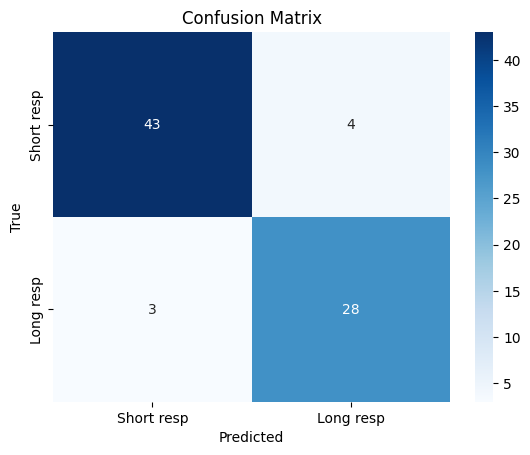

In [30]:
full_pipe.set_params(**study.best_params)

if BINARY_PFS == True:
    results = cross_validate(
        full_pipe, x, y,
        cv=skf,
        scoring=['roc_auc', 'f1'],
        return_train_score=True,
        n_jobs=-1,
        return_estimator=True
    )
    
    print(f"Train ROC-AUC : {results['train_roc_auc'].mean():.3f} ± {results['train_roc_auc'].std():.3f}")
    print(f"Train  F1     : {results['train_f1'].mean():.3f} ± {results['train_f1'].std():.3f}")
    print(f"Test ROC-AUC  : {results['test_roc_auc'].mean():.3f} ± {results['test_roc_auc'].std():.3f}")
    print(f"Test F1       : {results['test_f1'].mean():.3f} ± {results['test_f1'].std():.3f}\n")
    
    target_names = ['Short resp', 'Long resp']
else:
    results = cross_validate(
        full_pipe, x, y,
        cv=skf,
        scoring=['roc_auc_ovo', 'f1_macro'],
        return_train_score=True,
        n_jobs=-1,
        return_estimator=True
    )
    
    print(f"Train ROC-AUC (OVO): {results['train_roc_auc_ovo'].mean():.3f} ± {results['train_roc_auc_ovo'].std():.3f}")
    print(f"Train Macro F1     : {results['train_f1_macro'].mean():.3f} ± {results['train_f1_macro'].std():.3f}")
    print(f"Test ROC-AUC (OVO) : {results['test_roc_auc_ovo'].mean():.3f} ± {results['test_roc_auc_ovo'].std():.3f}")
    print(f"Test Macro F1      : {results['test_f1_macro'].mean():.3f} ± {results['test_f1_macro'].std():.3f}\n")
    
    target_names = ['Short resp', 'Intermediate', 'Long resp']

y_pred = cross_val_predict(
    full_pipe, x, y, 
    cv=skf,
    n_jobs=-1
)

print(classification_report(
    y, y_pred,
    target_names=target_names
))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names,
            yticklabels=target_names,
            cmap='Blues')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

Check how many genes overlap between folds

In [31]:
selected_per_fold = []
for tr, _ in skf.split(x, y):
    full_pipe.fit(x.iloc[tr], y.iloc[tr])
    names = full_pipe['preprocess'].get_feature_names_out()
    coefs = full_pipe['clf'].coef_[0]
    mask = coefs != 0
    selected_per_fold.append(set(names[mask]))

gex_per_fold = [{f for f in fold if f.startswith('remainder__')} for fold in selected_per_fold]

common_gex = set.intersection(*gex_per_fold)
union_gex  = set.union(*gex_per_fold)
sizes_gex  = [len(s) for s in gex_per_fold]

print(f"GEX per-fold sizes : {sizes_gex}")
print(f"GEX in all folds   : {len(common_gex)} → {common_gex}")
print(f"GEX union size     : {len(union_gex)}")
print(f"GEX stability ratio: {len(common_gex) / max(1, min(sizes_gex)):.2f}")

GEX per-fold sizes : [20, 20, 20, 20, 20]
GEX in all folds   : 20 → {'remainder__LATS2', 'remainder__ALDH5A1', 'remainder__SLC25A26', 'remainder__SLC36A1', 'remainder__TTYH3', 'remainder__NME7', 'remainder__FANCC', 'remainder__REEP4', 'remainder__CLN8', 'remainder__MIR23B', 'remainder__CXCR5', 'remainder__DOCK1', 'remainder__ADAM9', 'remainder__PGM3', 'remainder__PYROXD2', 'remainder__STX2', 'remainder__NOTCH1', 'remainder__POU5F1B', 'remainder__PTPDC1', 'remainder__TBC1D1'}
GEX union size     : 20
GEX stability ratio: 1.00


Check genes overlap with KEGG-VCELLS genes

In [32]:
with open("../dataset/additional/combine-kegg-vcells.txt") as f:
    kegg_vcells = {g.strip() for g in f.read().split(",")}

GEX_COLS_KEGG = [g for g in common_gex if g in kegg_vcells]

print(f"combine-kegg-vcells genes : {len(kegg_vcells)}")
print(f"GEX_COLS_FILTERED genes   : {len(common_gex)}")
print(f"Overlap (GEX_COLS_KEGG)   : {len(GEX_COLS_KEGG)}")

combine-kegg-vcells genes : 174
GEX_COLS_FILTERED genes   : 20
Overlap (GEX_COLS_KEGG)   : 0


Save best model (across different train-test splits) for explanability

In [33]:
print(results['test_roc_auc'])
print(results['test_f1'])

[0.86666667 0.98333333 0.93650794 0.98148148 0.92592593]
[0.83333333 0.92307692 0.85714286 0.90909091 0.92307692]


In [34]:
# import joblib
# import os

# fold_idx = 1    # choose fold 1 model

# best_pipeline = results["estimator"][fold_idx] 

# os.makedirs(f"../saved-models/{pfs_dir}", exist_ok=True)
# joblib.dump(best_pipeline, f'../saved-models/{pfs_dir}/best_pipeline{rna_suffix}.joblib')

In [35]:
splits = list(skf.split(x, y))
train_idx, test_idx = splits[fold_idx]   

x_train = x.iloc[train_idx]
x_test  = x.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]

# x_train.to_csv(f"../dataset/created/{pfs_dir}/x_train{rna_suffix}.csv", index=False)
# x_test.to_csv(f"../dataset/created/{pfs_dir}/x_test{rna_suffix}.csv", index=False)
# y_train.to_csv(f"../dataset/created/{pfs_dir}/y_train{rna_suffix}.csv", index=False)
# y_test.to_csv(f"../dataset/created/{pfs_dir}/y_test{rna_suffix}.csv", index=False)

NameError: name 'fold_idx' is not defined